In [1]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm


In [2]:
lengde = 20_000

def create_pop(lengde):
    population = {
        "sex":[random.choice(['K', 'M']) for _ in range(lengde)], 
        "alder":[random.randint(0, 100) for _ in range(lengde)],
        "barn": [0] * lengde
    
    }
    df = pd.DataFrame(population)
  
    return df

create_pop(100_000)

,sex,alder,barn
0,M,86,0
1,M,94,0
2,K,88,0
3,K,17,0
4,M,88,0
...,...,...,...
99995,K,84,0
99996,M,97,0
99997,K,33,0
99998,M,87,0


In [9]:
innvandring = pd.read_csv("nettoinvandring.csv")
innvandring

,år,nettoinnvandring
0,2007,39652
1,2008,43346
2,2009,38637
3,2010,42346
4,2011,47032
5,2012,47343
6,2013,40073
7,2014,38170
8,2015,29773
9,2016,26093


In [31]:
initial_value = innvandring.nettoinnvandring.mean()

percentage_change = -0.05

# Define the number of iterations
iterations = 102

# Create a list to store the values
values_list = [initial_value]

# Iteratively multiply the value by the percentage change
for i in range(1, iterations):
    new_value = values_list[-1] * (1 + percentage_change)
    values_list.append(new_value)

print(values_list)

[33878.333333333336, 32184.416666666668, 30575.19583333333, 29046.436041666664, 27594.11423958333, 26214.408527604162, 24903.688101223954, 23658.503696162756, 22475.578511354615, 21351.799585786885, 20284.209606497538, 19269.99912617266, 18306.499169864026, 17391.174211370824, 16521.615500802283, 15695.534725762169, 14910.75798947406, 14165.220090000355, 13456.959085500337, 12784.11113122532, 12144.905574664053, 11537.66029593085, 10960.777281134306, 10412.73841707759, 9892.10149622371, 9397.496421412523, 8927.621600341896, 8481.2405203248, 8057.1784943085595, 7654.319569593131, 7271.603591113474, 6908.0234115578, 6562.622240979909, 6234.491128930914, 5922.766572484368, 5626.628243860149, 5345.296831667141, 5078.031990083784, 4824.130390579595, 4582.923871050615, 4353.777677498084, 4136.088793623179, 3929.28435394202, 3732.820136244919, 3546.179129432673, 3368.8701729610393, 3200.426664312987, 3040.4053310973377, 2888.385064542471, 2743.9658113153473, 2606.76752074958, 2476.42914471210

NameError: name 'num' is not defined

In [391]:
import pandas as pd
import random
from tqdm import tqdm


def get_age_group(age):
    if age < 25:
        return 'child'
    elif age < 65:
        return 'adult'
    else:
        return 'senior'
    

def populasjonsutvikling(df, TFR, år, fruktbare_år, eldste_fødsel, innvandring=True,  innvandringsgrad = 0.95):
    print(f"Regner populasjon med\nTFR={TFR}\nFruktbare år: {fruktbare_år}\nEldste fødsel: {eldste_fødsel}\n{år} år")
    
    liste_med_antall_personer = []
    sannsynlighet_for_barn = TFR / fruktbare_år
    

    for year in tqdm(range(år)):
        # Legger til 1 i alder på hele populasjonen
        df['alder'] += 1
        yearly_pop.append(len(df))
        
        # Definerer fruktbare damer
        fruktbare_damer = df.loc[(df.alder > eldste_fødsel-fruktbare_år) & (df.alder < eldste_fødsel) & (df.barn < 4) & (df.sex == "K")]
        num_fruktbare_damer = len(fruktbare_damer)
        # Henter antall nye kids
        num_nye_kids = int(num_fruktbare_damer * sannsynlighet_for_barn)

        nye_kids = (
            pd.DataFrame({
                "sex": [random.choice(['K', 'M']) for _ in range(num_nye_kids)], 
                "alder": [0] * num_nye_kids,
                "barn": [0] * num_nye_kids}))
        
        # øker antall barn for damene som får barn.
        df.loc[fruktbare_damer.sample(num_nye_kids, random_state=42).index, "barn"] += 1

        # Assign weights once
        df['age_group'] = df['alder'].apply(get_age_group)
        df['weights'] = df['age_group'].map(age_groups)
        
        # Regner ut antall døe personer
        antall_døde = int(len(df) * dødsrate)
        døde = df.sample(n=antall_døde, weights='weights', random_state=42).index
        df = df.drop(døde)
        
        # legger til innvandring i populasjonen
        if innvandring == True:
            if year in [0,1]:
                innvandrere = 40_000
            else:
                innvandrere = int(40_000 * innvandringsgrad**year)
        else:
            innvandrere = 0

        innvandrere_df = (
            pd.DataFrame({
                "sex": [random.choice(['K', 'M']) for _ in range(innvandrere)], 
                "alder": [0] * innvandrere,
                "barn": [0] * innvandrere}))

        df = pd.concat([df, nye_kids, innvandrere_df]).reset_index(drop=True)
        df.drop(columns=['weights'], inplace=True)

        liste_med_antall_personer.append(len(df))
        
        
    return liste_med_antall_personer, df

In [392]:
befolkning_for_2023 = pd.read_csv("befolkning.csv")#.loc[lambda x: x.år <= 2022]
befolkning_for_2023

FileNotFoundError: [Errno 2] No such file or directory: 'befolkning.csv'

In [250]:
start_pop = befolkning_for_2023.loc[lambda x: x.år == 2024, "pop"].values[0]
start_pop

5550203

In [390]:
2150 - 1986

164

In [351]:
# Demonstrasjon av Norge


befolkningsutvikling = pd.DataFrame()
år_start = 1986
år = 164
år_slutt = (år_start) + (2025 - år_start) + år
fruktbare_år = 15
eldste_fødsel = 35
befolkningsutvikling["år"] = range(år_start, år_slutt)
# befolkningsutvikling


In [352]:
tfrs = [1.4]

for tfr in tfrs:
    df_for_run = create_pop(start_pop)
    utvikling = populasjonsutvikling(df_for_run, tfr, år, fruktbare_år, eldste_fødsel)
    utvikling = pd.concat([befolkning_for_2023["pop"], pd.Series(utvikling)]).reset_index(drop=True)
    befolkningsutvikling[f"pop_{tfr}"] = utvikling

Regner populasjon med
TFR=1.4
Fruktbare år: 15
Eldste fødsel: 35
250 år


100% 250/250 [08:03<00:00,  1.93s/it]


Regner populasjon med
TFR=2.1
Fruktbare år: 15
Eldste fødsel: 35
250 år


100% 250/250 [13:28<00:00,  3.23s/it]


Regner populasjon med
TFR=2.7
Fruktbare år: 15
Eldste fødsel: 35
250 år


100% 250/250 [25:25<00:00,  6.10s/it]


In [363]:
befolkningsutvikling

,år,pop_1.4,pop_2.1,pop_2.7
0,1986,4159187,4159187,4159187
1,1987,4175521,4175521,4175521
2,1988,4198289,4198289,4198289
3,1989,4220686,4220686,4220686
4,1990,4233116,4233116,4233116
...,...,...,...,...
284,2270,1946844,6849164,24528869
285,2271,1932802,6839861,24663533
286,2272,1918852,6830577,24799134
287,2273,1904994,6821318,24935631


<Axes: xlabel='år'>

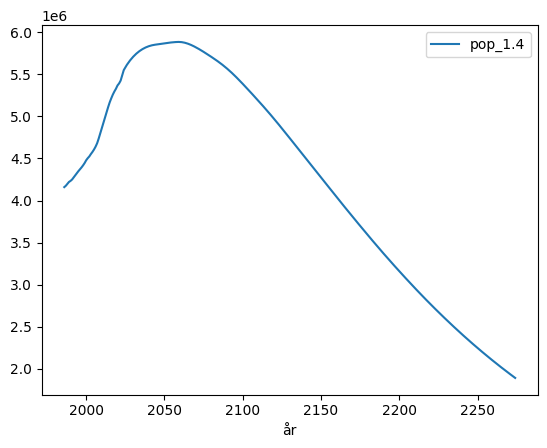

In [368]:
(
    befolkningsutvikling
   # .loc[lambda x: x.år < 2100]
    
    .plot(x="år", y = befolkningsutvikling.columns[1]))

In [380]:
befolkning_14_fremskrivning = befolkningsutvikling[["år", "pop_1.4"]].loc[lambda x: x.år < 2151]

In [381]:
start_pop = list(befolkning_14_fremskrivning["pop_1.4"])[-1]
start_pop

4274819

In [382]:
befolkning_14_fremskrivning

,år,pop_1.4
0,1986,4159187
1,1987,4175521
2,1988,4198289
3,1989,4220686
4,1990,4233116
...,...,...
160,2146,4368619
161,2147,4345202
162,2148,4321758
163,2149,4298292


In [384]:
befolkning_14_fremskrivning.to_csv("befolknings_14_til_fremskrivning.csv", index=False)

In [385]:
# Demonstrasjon av Norge

befolkningsutvikling = pd.DataFrame()
år_start = 2150
år = 10
år_slutt = (år_start) + (2025 - år_start) + år
fruktbare_år = 15
eldste_fødsel = 35
befolkningsutvikling["år"] = range(år_start, år_slutt)
# befolkningsutvikling


In [388]:
tfrs = (
    [
        1.7, 
        2.1, 
        2.8
    ]
)

for tfr in tfrs:
    df_for_run = create_pop(start_pop)
    utvikling = populasjonsutvikling(df_for_run, tfr, år, fruktbare_år, eldste_fødsel, innvandring = False)
    utvikling = pd.Series(utvikling).reset_index(drop=True)
    befolkningsutvikling[f"pop_{tfr}"] = utvikling

Regner populasjon med
TFR=1.7
Fruktbare år: 15
Eldste fødsel: 35
10 år


100% 10/10 [00:21<00:00,  2.11s/it]


Regner populasjon med
TFR=2.1
Fruktbare år: 15
Eldste fødsel: 35
10 år


100% 10/10 [00:20<00:00,  2.06s/it]


Regner populasjon med
TFR=2.8
Fruktbare år: 15
Eldste fødsel: 35
10 år


100% 10/10 [00:21<00:00,  2.11s/it]


In [389]:
befolkningsutvikling

,år,pop_1.7,pop_2.1,pop_2.8
0,NaN,4274137.0,4282092.0,4295800.0
1,NaN,4273390.0,4289219.0,4316493.0
2,NaN,4272582.0,4296247.0,4336966.0
3,NaN,4271738.0,4303143.0,4357238.0
4,NaN,4270801.0,4309925.0,4377186.0
5,NaN,4269821.0,4316562.0,4396745.0
6,NaN,4268762.0,4322980.0,4415800.0
7,NaN,4267629.0,4329194.0,4434313.0
8,NaN,4266439.0,4335158.0,4452248.0
9,NaN,4265189.0,4340887.0,4469459.0
